In [1]:
import json
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
from collections import Counter
from torchvision.datasets import ImageFolder
from torchvision import transforms
from tqdm import tqdm

os.chdir("C:/Users/HP/Desktop/Brain_Cancer_MRI")

from src.data.data_module import BrainMRIDataModule
from src.utils.file_io import load_config, load_objects
from src.utils.visualizations import class_counter, plot_raw_vs_transformed_imgs, plot_train_vs_val, plot_learning_rates

#### Loading the global configurations file

In [2]:
configs = load_config("configs/config.yaml")

#### Checking the device

#### Checking the classes in the dataset

In [3]:
data_dir = "data/Brain_Cancer"
if os.path.exists(data_dir):
    ln_items = os.listdir(data_dir)
    print(ln_items)

['brain_glioma', 'brain_menin', 'brain_tumor']


#### Getting the datasets and their data loaders

In [4]:
data_module = BrainMRIDataModule(configs)
train_dataset, val_dataset, test_dataset = data_module.get_datasets(save_mean_std_path="artifacts/preprocessing/normalization_mean_std.json")
train_loader, val_loader, test_loader = data_module.get_dataloaders()

####  Plotting the class distribution for the training set.

100%|██████████| 4542/4542 [00:39<00:00, 114.85it/s]


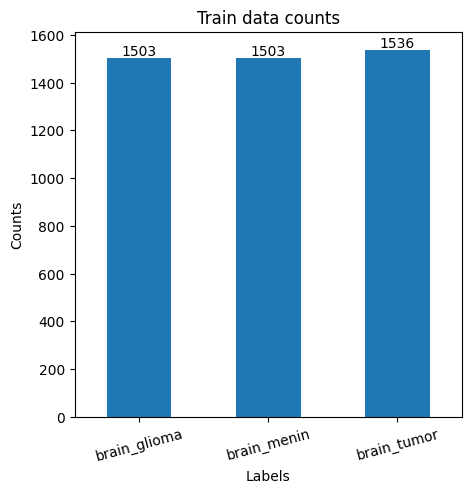

brain_glioma    1503
brain_menin     1503
brain_tumor     1536
dtype: int64

In [5]:
class_counter(train_dataset, title="Train data counts", savename="train_counts")

####  Plotting the class distribution for the training set.

100%|██████████| 756/756 [00:04<00:00, 158.10it/s]


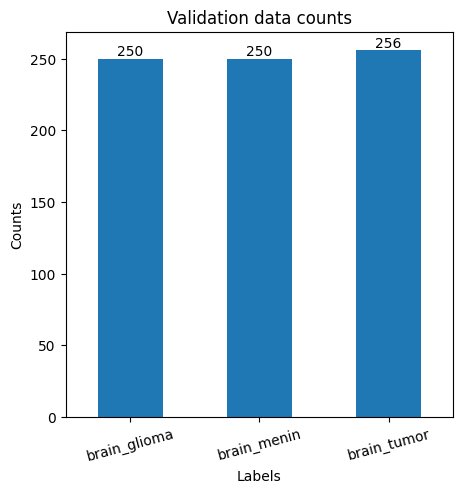

brain_glioma    250
brain_menin     250
brain_tumor     256
dtype: int64

In [6]:
class_counter(val_dataset, title="Validation data counts", savename="val_counts")

####  Plotting the class distribution for the training set.

100%|██████████| 758/758 [00:04<00:00, 164.90it/s]


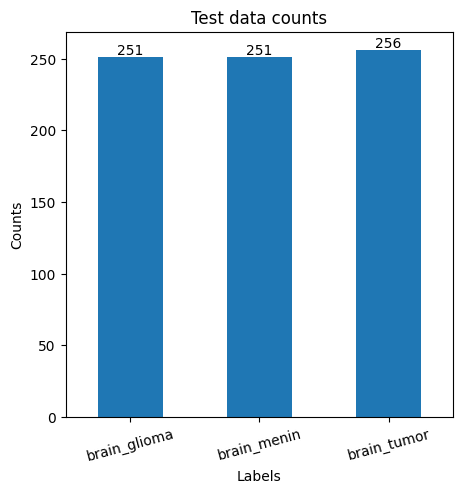

brain_glioma    251
brain_menin     251
brain_tumor     256
dtype: int64

In [7]:
class_counter(test_dataset, title="Test data counts", savename="test_counts")

From the three graphs above, we can obviously all splits and the dataset as a whole is balanced. This is very good as we need not worry about dealing with all the problems that come with imbalanced dataset. Ironically, in most medical datasets, this is contrary. Most (if not all) medical data has class imbalance.

####  Plotting the raw images vs the transformed images

This will help up us visualize the effects of the augmentations applied to the training data. This is 
necessary as it alows the model to learn different representations. For a full read of the augmentations 
applied to the training set, see [data module]("src/data/data_module.py") class.

[0.1545172482728958, 0.1545172482728958, 0.1545172482728958] [0.1720396727323532, 0.1720396727323532, 0.1720396727323532]


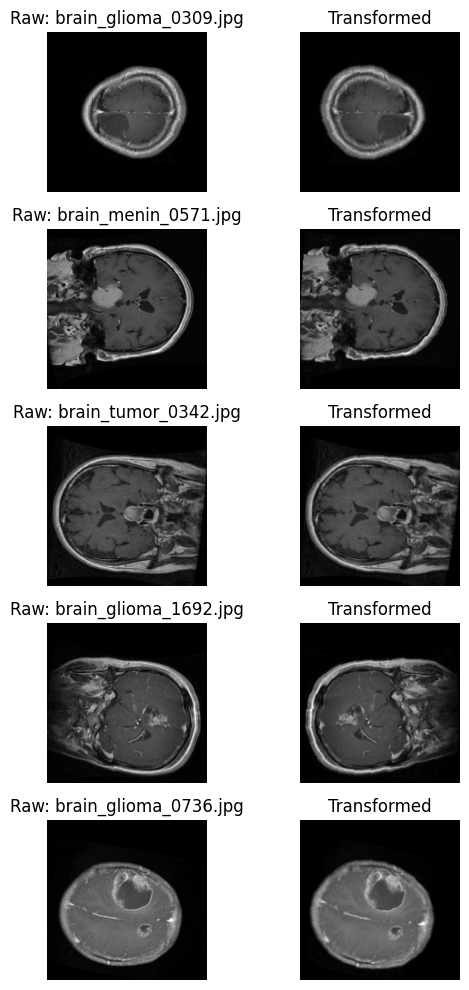

In [14]:
   
with open("artifacts/preprocessing/normalization_mean_std.json") as f:
    saved_mean_std = json.load(f)
mean, std = saved_mean_std["mean"], saved_mean_std["std"]

plot_raw_vs_transformed_imgs(dataset=train_dataset, n_samples=5, mean=mean, std=std, config=configs, save_name="raw_vs_transformed_imgs")

#### Plotting the training vs validation loss

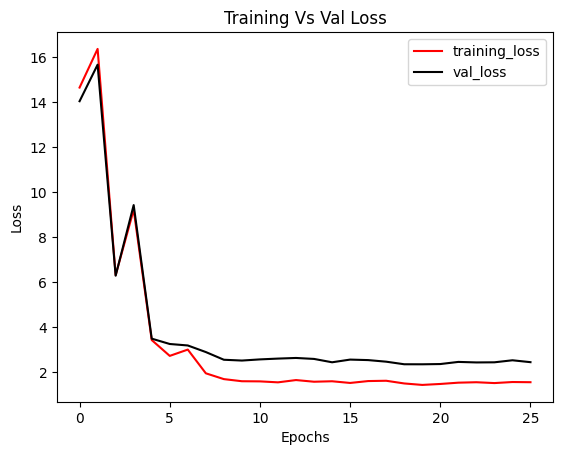

In [9]:
history = load_objects("artifacts/history/history_brain_cnn_baseline.pth")
    
plot_train_vs_val(history=history, metric="loss", title="Training Vs Val Loss", y_label="Loss", save_name="train_vs_val_loss")


#### Plotting the training vs validation accuracy

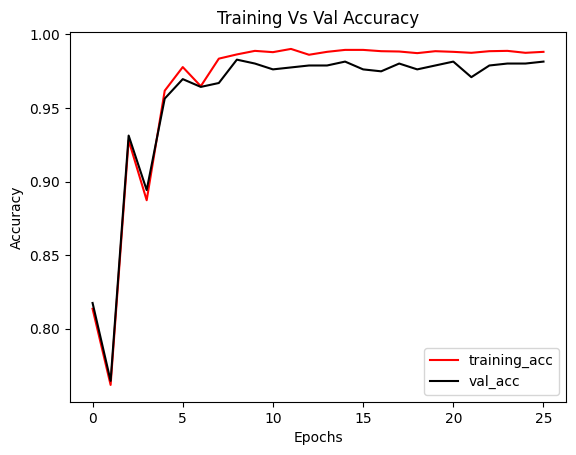

In [10]:
plot_train_vs_val(history=history, metric="acc", title="Training Vs Val Accuracy", y_label="Accuracy", save_name="train_vs_val_accuracy")

#### Plotting the training vs validation f1-macro score

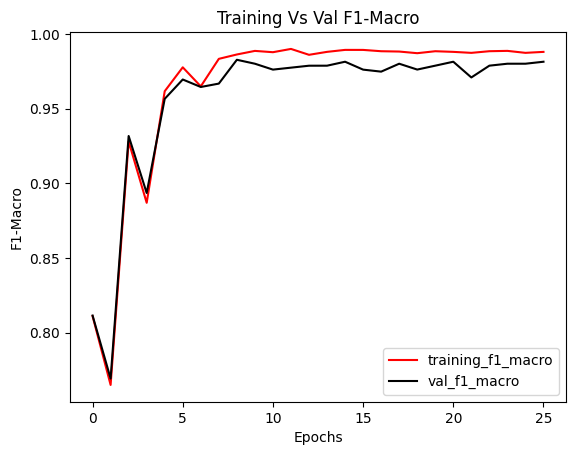

In [11]:
plot_train_vs_val(history=history, metric="f1_macro", title="Training Vs Val F1-Macro", y_label="F1-Macro", save_name="train_vs_val_f1_macro")

#### Plotting the training vs validation f1-weighted score

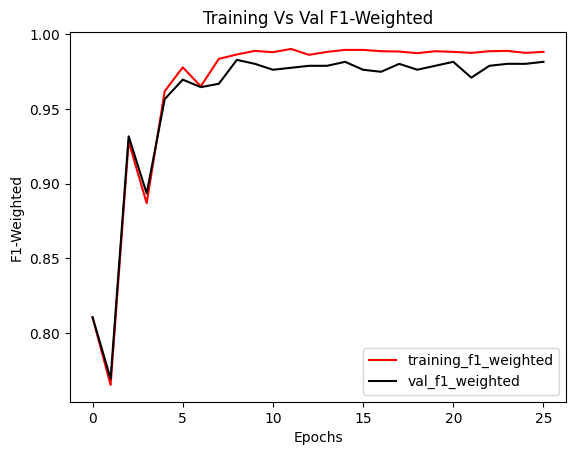

In [12]:
plot_train_vs_val(history=history, metric="f1_weighted", title="Training Vs Val F1-Weighted", y_label="F1-Weighted", save_name="train_vs_val_g1_weighted")

The graphs above shows us that the model seem to be performing extremely well. Also, it is important to note that there's no obvious sign that the model is overfitting as the validation metrics (although slightly lower or higher in the case of loss), are very close to that of the training metrics. This attests to the robustness of the model.

#### Plotting the learning rates for the trained epochs.

It is worth noting that the learning rate scheduler used in this project is the StepLR scheduler with a step size of 4.

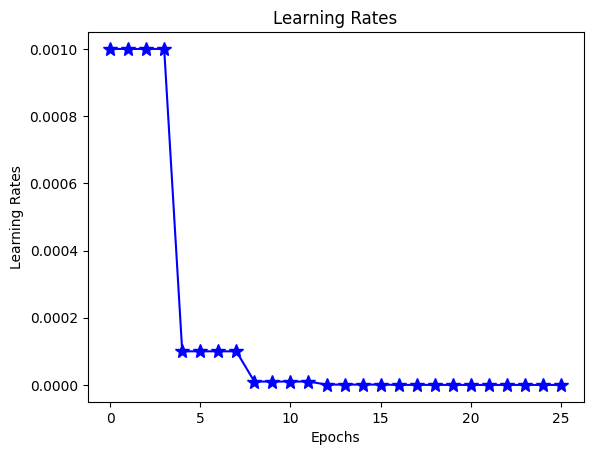

In [13]:
plot_learning_rates(history, color="b", marker="*", markersize=10, title="Learning Rates", save_name="learning_rates")

In [ ]:
targets = []
for _, labels in test_loader:
    targets.extend(labels.numpy().tolist())
predictions, prediction_probs = predict(test_loader, model=model, device=device)
get_confusion_matrix(targets=targets, predictions=predictions, class_names=class_names, save_name="confusion_matrix_eval_basline_cnn")